In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans,DBSCAN
from sklearn.decomposition import PCA
from datetime import datetime as dt

### loading dataset

In [2]:
df=pd.read_csv('online_retail_II.csv')

### EDA

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df=df.drop_duplicates()

In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


### remove the customer id which is null

In [7]:
df=df.dropna(subset='Customer ID')

In [8]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

### remove the invoice which start with 'C' represent cancel order

In [9]:
df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779495 non-null  object 
 1   StockCode    779495 non-null  object 
 2   Description  779495 non-null  object 
 3   Quantity     779495 non-null  int64  
 4   InvoiceDate  779495 non-null  object 
 5   Price        779495 non-null  float64
 6   Customer ID  779495 non-null  float64
 7   Country      779495 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 53.5+ MB


### focus on positive and non zero 

In [11]:
df=df[df['Quantity']>0]
df=df[df['Price']>0]

In [12]:
df['Total_Price']=df['Quantity']*df['Price']

In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [13]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [13]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### now date for recency 

In [14]:
now=df['InvoiceDate'].max()+pd.Timedelta(days=1)

In [17]:
now

Timestamp('2011-12-10 12:50:00')

### Recency : customer last purchase
### Frequency:Number of unique transactions in history window
### Monetary :Total spend in history window

In [75]:
rfm=df.groupby('Customer ID').agg(
                       recency = ('InvoiceDate',lambda x:(now-x.max()).days),
                        frequency =('Invoice','nunique'),
                        monetary =('Total_Price','sum')
       ).reset_index()

In [76]:
rfm.head()

,Customer ID,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [77]:
rfm=rfm.drop(columns=['Customer ID'])

In [78]:
rfm.head()

,recency,frequency,monetary
0,326,12,77556.46
1,2,8,4921.53
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40


### this is function to check the skew of graph

In [79]:
def to_look(df):
    for col in rfm.columns:
        plt.figure(figsize=(12,6))
        sns.histplot(data=rfm,x=col)
        plt.title(f'{col} and skewness is {rfm[col].skew():.3f}')
        plt.show()

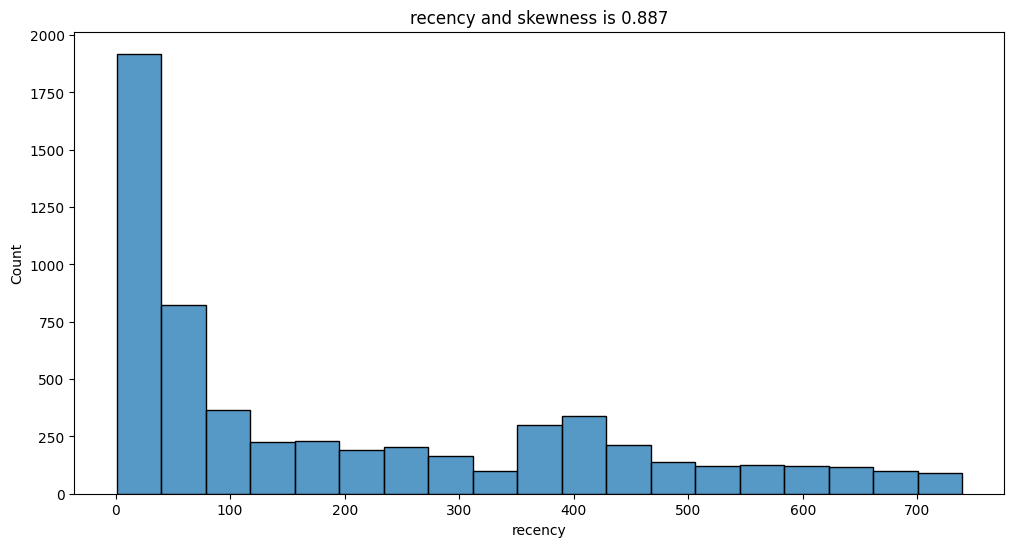

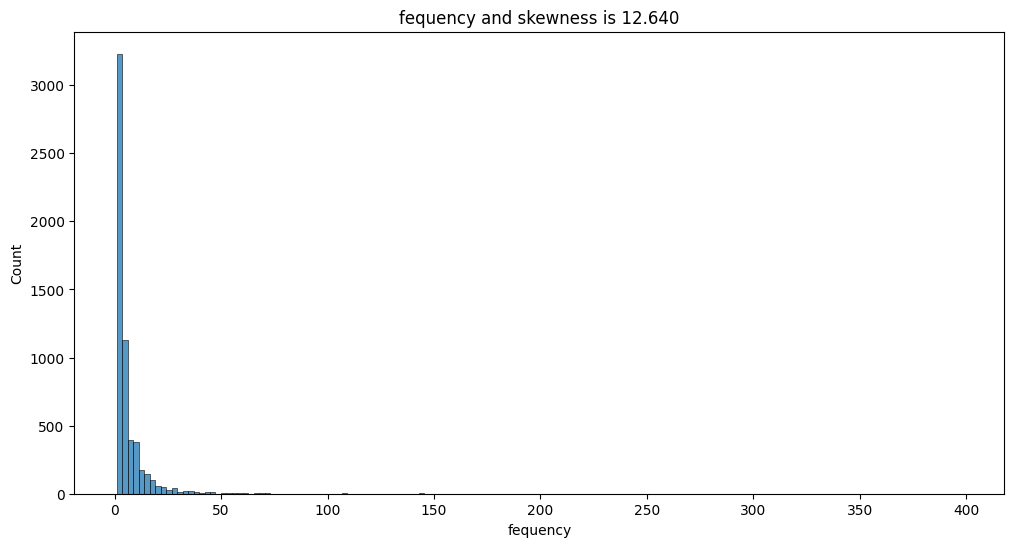

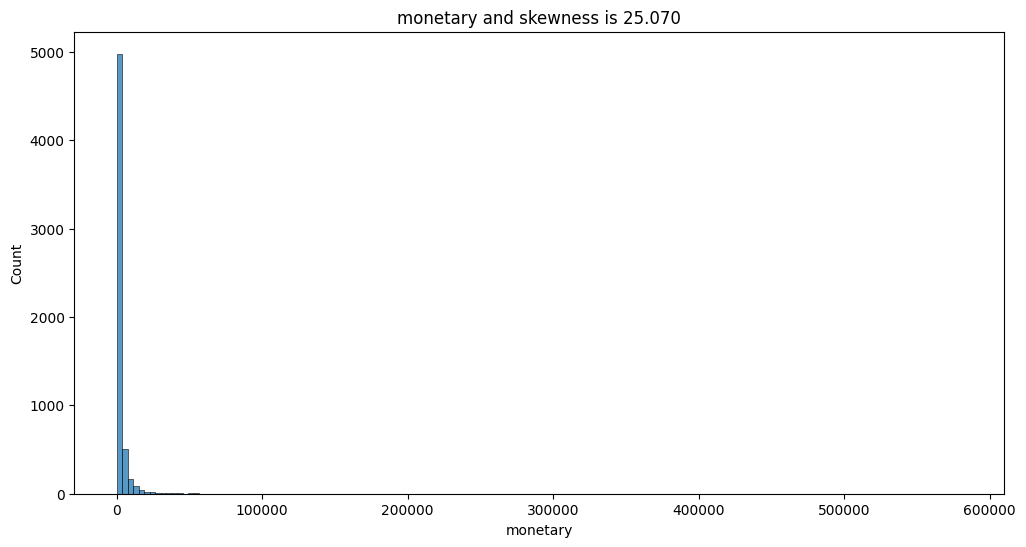

In [19]:
to_look(rfm)

##     outlier treatment
###      Clipping restricts data to a specific range by pulling values below the lower limit up and          values above the upper limit down to the nearest boundary

In [20]:
for col in rfm.columns[2:]:
    lo,hi=rfm[col].quantile([.01,.99])
    rfm[col]=rfm[col].clip(lo,hi)


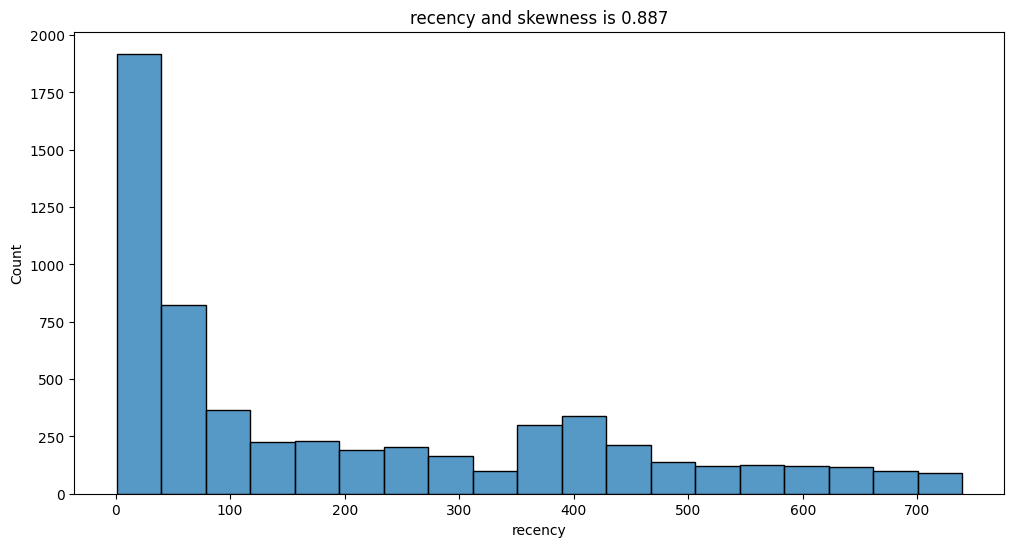

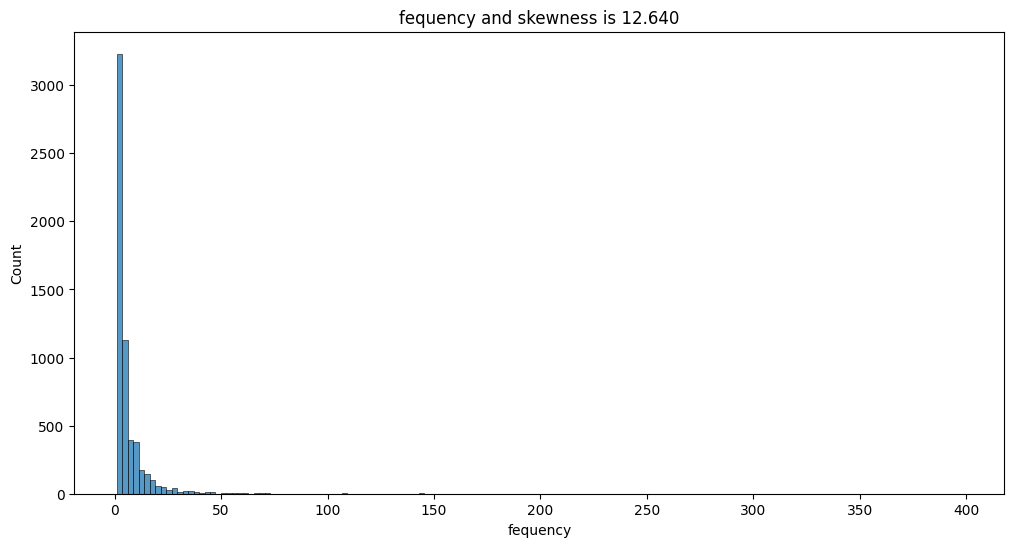

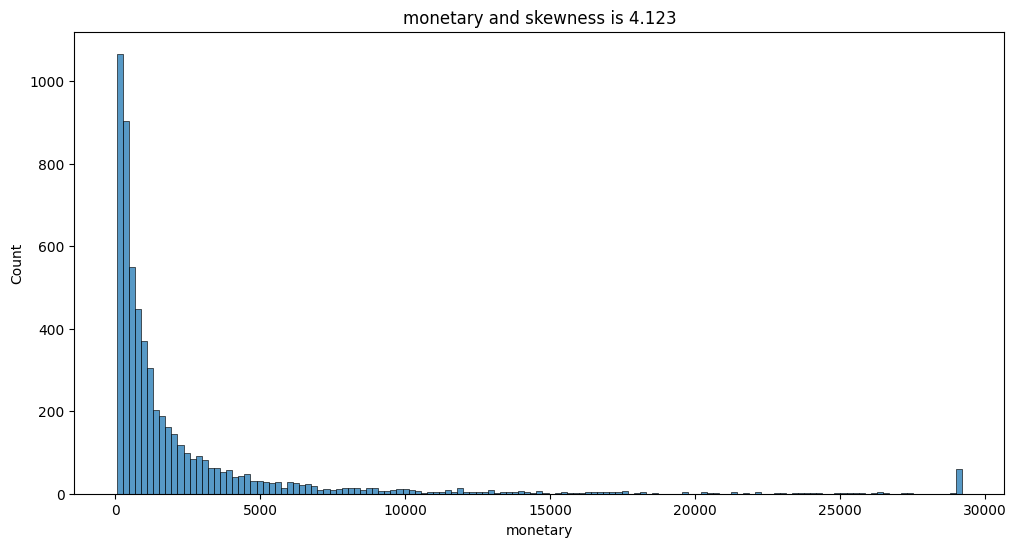

In [21]:
to_look(rfm)

### log Transformation : Shrinks the whole scale. It keeps the "rank" of the outliers but makes the distances smaller

In [22]:
rfm['fequency']=np.log1p(rfm['fequency'])
rfm['monetary']=np.log1p(rfm['monetary'])


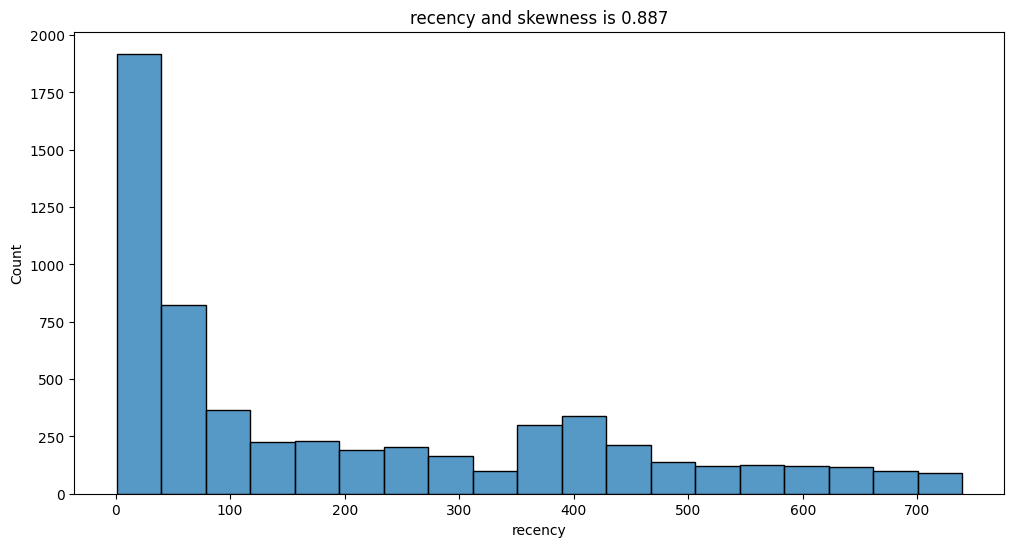

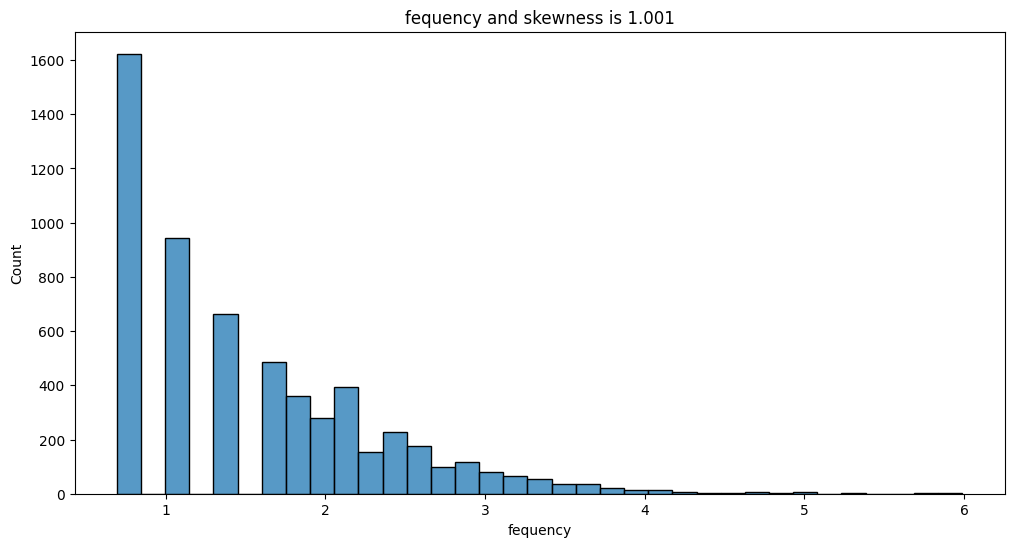

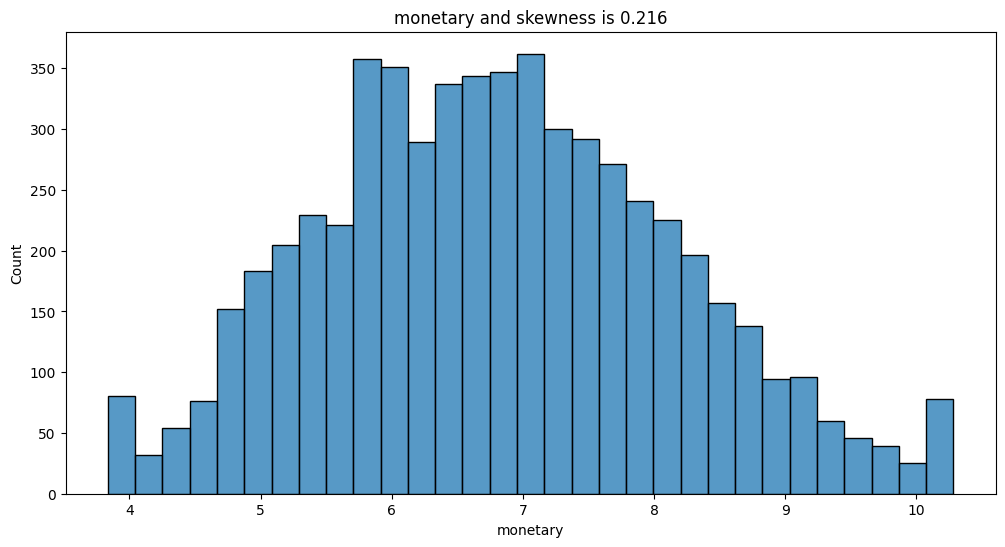

In [23]:
to_look(rfm)

In [57]:
x_scaled=StandardScaler().fit_transform(rfm)

In [48]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

/tmp/ipykernel_5688/3639357501.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],palette='viridis')


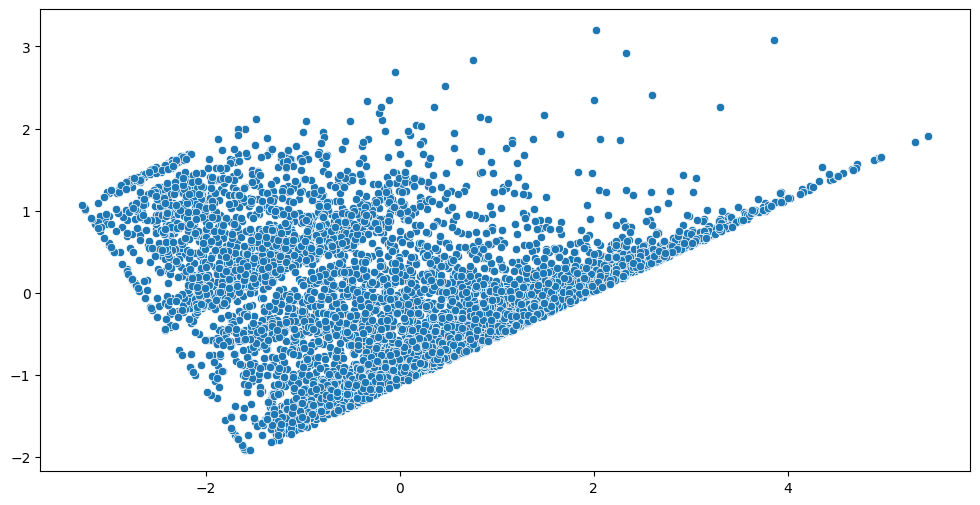

In [49]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],palette='viridis')
plt.show()

In [51]:
K_range=range(2,11)
inertia=[]
for k in K_range:
    kmeans=KMeans(random_state=42,n_init=10,init='k-means++',n_clusters=k)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

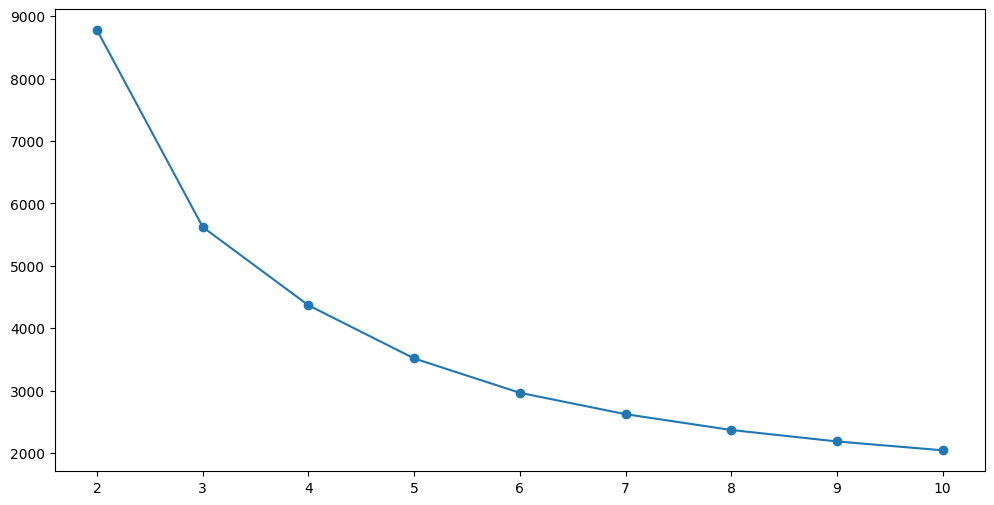

In [52]:
plt.figure(figsize=(12,6))
plt.plot(K_range,inertia,marker='o')
plt.show()

In [58]:
silhouette_scores=[]
for k in K_range:
    kmeans=KMeans(n_clusters=k,n_init=10,init='k-means++',random_state=92)
    label=kmeans.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,label)
    silhouette_scores.append(score)
    print(f'K={k} and silhoette score{score:.4f}')

K=2 and silhoette score0.4208
K=3 and silhoette score0.4017
K=4 and silhoette score0.3622
K=5 and silhoette score0.3690
K=6 and silhoette score0.3505
K=7 and silhoette score0.3369
K=8 and silhoette score0.3172
K=9 and silhoette score0.3110
K=10 and silhoette score0.3156


In [59]:
kmeans=KMeans(n_init=10,init='k-means++',random_state=42,n_clusters=3)
rfm['labels']=kmeans.fit_predict(x_scaled)

In [60]:
pca_d=pd.DataFrame(data=x_pca,columns=['pca1','pca2'])
pca_d['label']=rfm['labels']

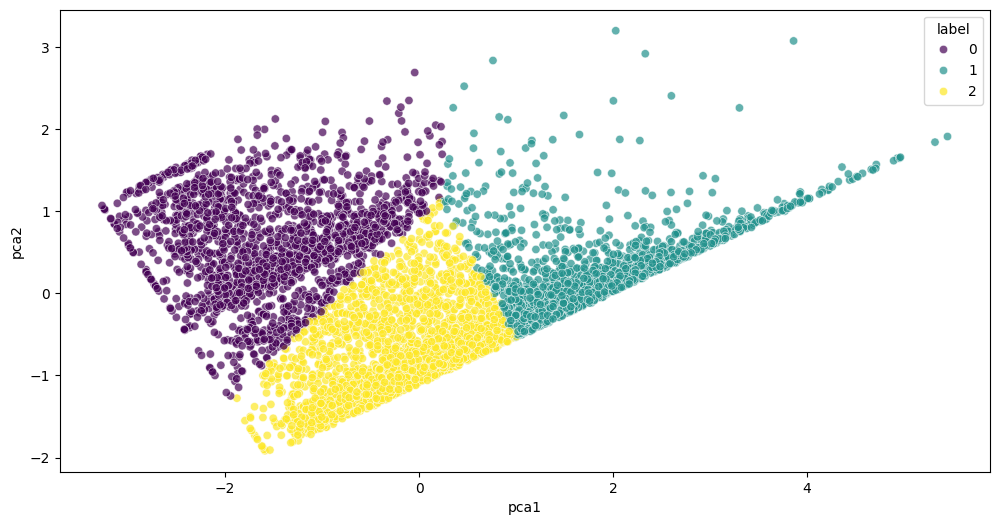

In [61]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=pca_d,x='pca1',y='pca2',hue='label',palette='viridis',alpha=.7)
plt.show()

In [62]:
rfm.groupby('labels').mean()

,recency,fequency,monetary
labels,,,
0,472.980413,0.950200,5.820510
1,58.859393,2.560814,8.389003
2,91.662081,1.278062,6.440696


In [71]:

segment_map = {
    0: 'At Risk / Churn',
    1: 'Loyal Customers',
    2: 'Champions / VIP',
    3: 'New Customers'
}

# Apply the map
rfm['segment'] = rfm['labels'].map(segment_map)

# Check the distribution
print(rfm['segment'].value_counts())

segment
Champions / VIP    2326
At Risk / Churn    1838
Loyal Customers    1714
Name: count, dtype: int64


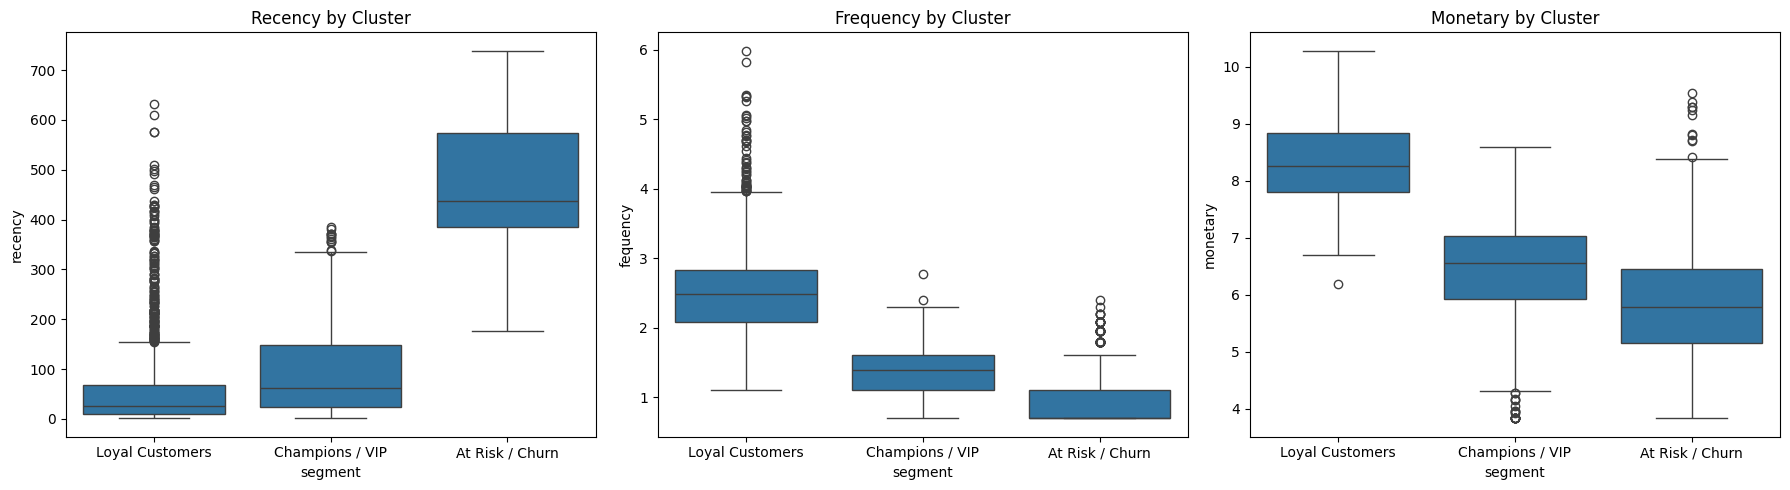

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='segment', y='recency', data=rfm, ax=axs[0])
axs[0].set_title('Recency by Cluster')

sns.boxplot(x='segment', y='fequency', data=rfm, ax=axs[1])
axs[1].set_title('Frequency by Cluster')

sns.boxplot(x='segment', y='monetary', data=rfm, ax=axs[2])
axs[2].set_title('Monetary by Cluster')

plt.tight_layout()
plt.show()